In [89]:
import warnings
warnings.filterwarnings("ignore", message="use_inf_as_na option is deprecated")

In [91]:
import pandas as pd 
df = pd.read_csv('/Users/linhhuynh/Desktop/DSC630/dtbases/Flight-Price.csv')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR ? DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU ? IXR ? BBI ? BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL ? LKO ? BOM ? COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU ? NAG ? BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR ? NAG ? DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### EDA - Initial EDA: Find and understand problems

In [94]:
# Check the shape of the data
print("Shape of dataset:", df.shape)

Shape of dataset: (10683, 11)


In [96]:
# Summary statistics
print("\nSummary statistics:\n", df.describe(include='all'))


Summary statistics:
             Airline Date_of_Journey Source Destination            Route  \
count         10683           10683  10683       10683            10682   
unique           12              44      5           6              128   
top     Jet Airways      18/05/2019  Delhi      Cochin  DEL ? BOM ? COK   
freq           3849             504   4537        4537             2376   
mean            NaN             NaN    NaN         NaN              NaN   
std             NaN             NaN    NaN         NaN              NaN   
min             NaN             NaN    NaN         NaN              NaN   
25%             NaN             NaN    NaN         NaN              NaN   
50%             NaN             NaN    NaN         NaN              NaN   
75%             NaN             NaN    NaN         NaN              NaN   
max             NaN             NaN    NaN         NaN              NaN   

       Dep_Time Arrival_Time Duration Total_Stops Additional_Info  \
count   

In [98]:
# Check data types and nulls
print("\nInfo:\n")
df.info()


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [100]:
# Check for missing values
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64


### Data Cleaning

In [103]:
# Drop Missing Values
df = df.dropna()

In [105]:
# Replace infinities with NaN, then drop them
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [107]:
# Fix the Duration Column
# Ensure all durations have both hours and minutes
df['Duration'] = df['Duration'].apply(lambda x: x.strip())

# Handle missing minutes or hours
df['Duration'] = df['Duration'].apply(lambda x: x.replace('h', 'h ').replace('m', 'm ').strip())
df['Duration'] = df['Duration'].apply(lambda x: '0h ' + x if 'h' not in x else x)
df['Duration'] = df['Duration'].apply(lambda x: x + ' 0m' if 'm' not in x else x)

# Extract hours and minutes and convert to total minutes
df['Duration_mins'] = df['Duration'].apply(
    lambda x: int(x.split('h')[0].strip()) * 60 + int(x.split('h')[1].strip().replace('m', '').strip())
)

In [109]:
# Check for Inconsistencies or Junk Values
for col in ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info']:
    print(f"\nUnique values in {col}:\n", df[col].value_counts())


Unique values in Airline:
 Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

Unique values in Source:
 Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64

Unique values in Destination:
 Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

Unique values in Total_Stops:
 Total_Stops
1 stop      5625
non-stop    3491
2 stops     1520
3 stops       45

In [111]:
# Convert Date_of_Journey to datetime and extract day/month/weekday
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')
df['Journey_Day'] = df['Date_of_Journey'].dt.day
df['Journey_Month'] = df['Date_of_Journey'].dt.month
df['Journey_Weekday'] = df['Date_of_Journey'].dt.dayofweek  # Monday=0, Sunday=6

# Clean and extract hour from Dep_Time and Arrival_Time
df['Dep_Time'] = df['Dep_Time'].str.strip().str.split().str[0]
df['Arrival_Time'] = df['Arrival_Time'].str.strip().str.split().str[0]

df['Dep_Hour'] = pd.to_datetime(df['Dep_Time'], format='%H:%M').dt.hour
df['Arrival_Hour'] = pd.to_datetime(df['Arrival_Time'], format='%H:%M').dt.hour

In [113]:
# Drop original columns 
df.drop(['Date_of_Journey', 'Dep_Time', 'Arrival_Time'], axis=1, inplace=True)

### Post-cleaning EDA: Visualize trends 

#### Histograms - Distribution of Numeric Features

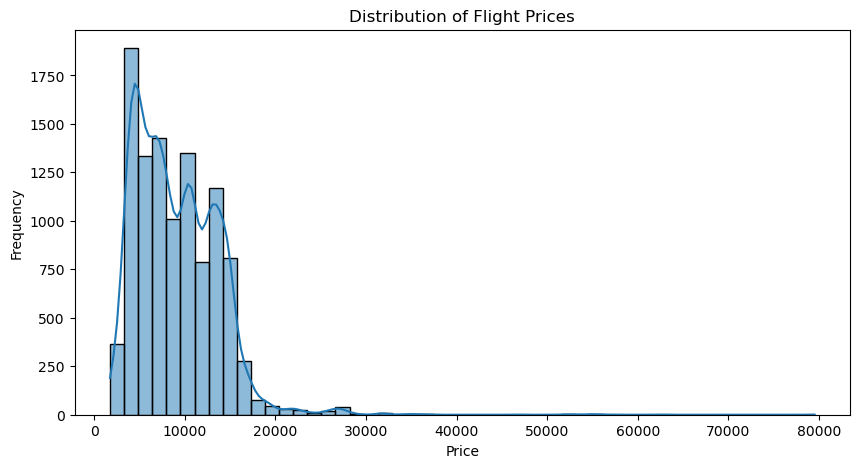

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

# Price Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

The flight price distribution is right-skewed, with most prices between 2,000 and 15,000, and a few very high outliers above 30,000.


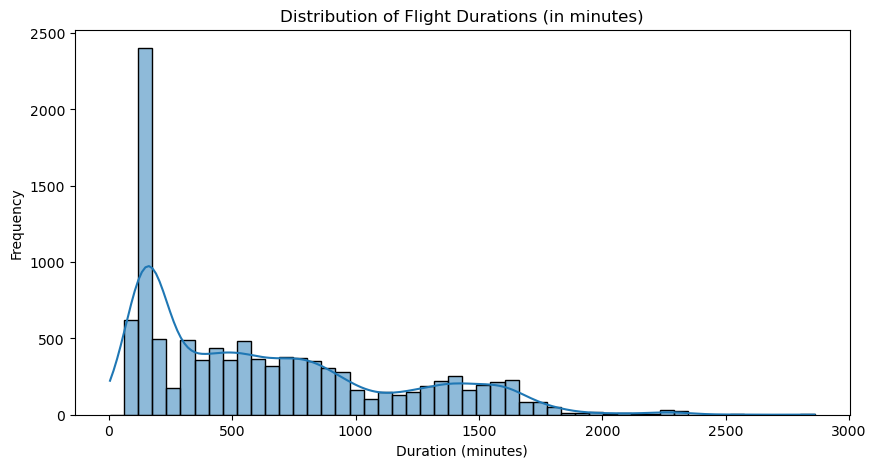

In [120]:
# Duration Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Duration_mins'], bins=50, kde=True)
plt.title('Distribution of Flight Durations (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

The flight duration distribution is right-skewed, with most flights lasting under 500 minutes and a few long flights over 2000 minutes acting as outliers.


####  Boxplots - Check Price Variation Across Categories

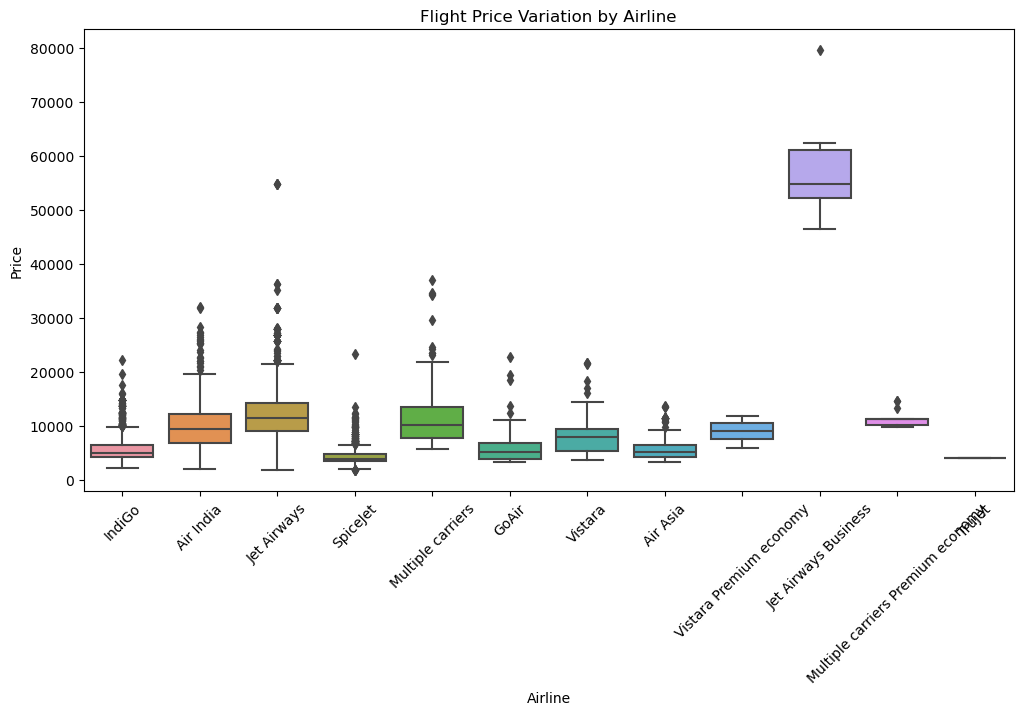

In [124]:
# Price vs Airline
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Airline', y='Price')
plt.xticks(rotation=45)
plt.title('Flight Price Variation by Airline')
plt.show()

Budget airlines like IndiGo and SpiceJet offer the lowest prices, while Jet Airways Business is the most expensive, with premium classes showing stable prices and regular classes having more variation.


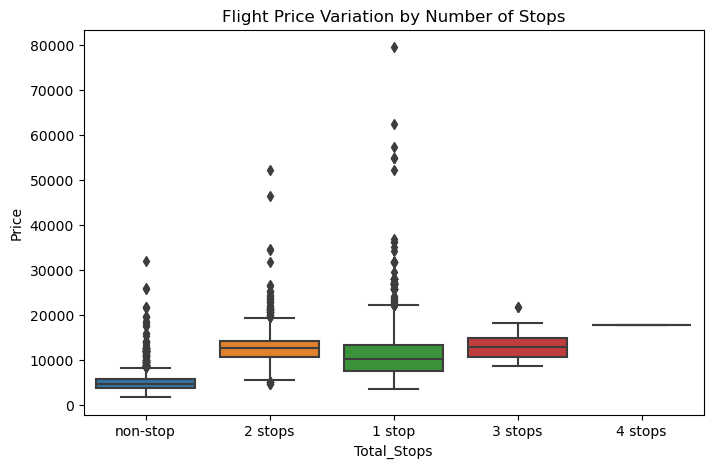

In [127]:
# Price vs Total Stops
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Total_Stops', y='Price')
plt.title('Flight Price Variation by Number of Stops')
plt.show()

Flights with 1 or 2 stops generally cost more than non-stop ones, while 4-stop flights have fixed high prices, and 3-stop flights show less variation but are also pricey.

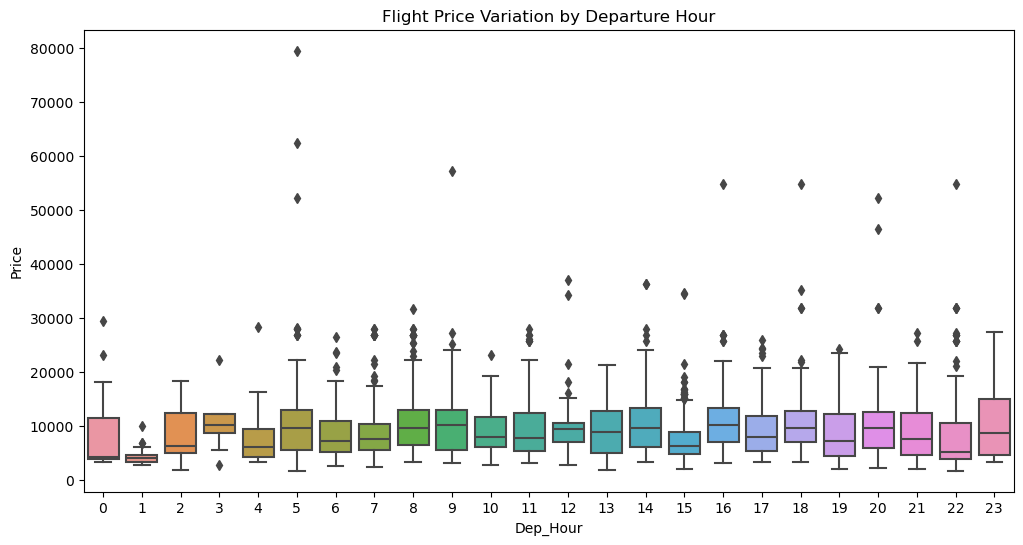

In [130]:
# Price vs Departure Hour
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Dep_Hour', y='Price')
plt.title('Flight Price Variation by Departure Hour')
plt.show()

Flight prices are generally higher during early morning (0–2 AM) and late-night (11 PM) departures, while midday to evening hours (10 AM–8 PM) show more stable and moderate pricing.

#### Bar Charts - Compare Categories

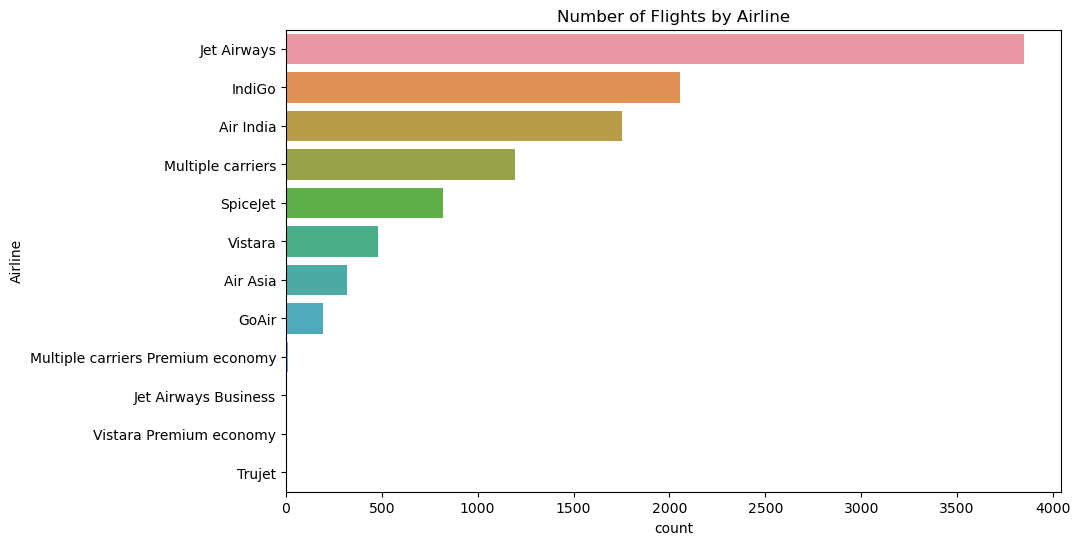

In [134]:
# Count of flights per airline
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Airline', order=df['Airline'].value_counts().index)
plt.title('Number of Flights by Airline')
plt.show()

Jet Airways operates the most flights by far, followed by IndiGo, Air India, and Multiple carriers, while premium services and TruJet have the fewest.

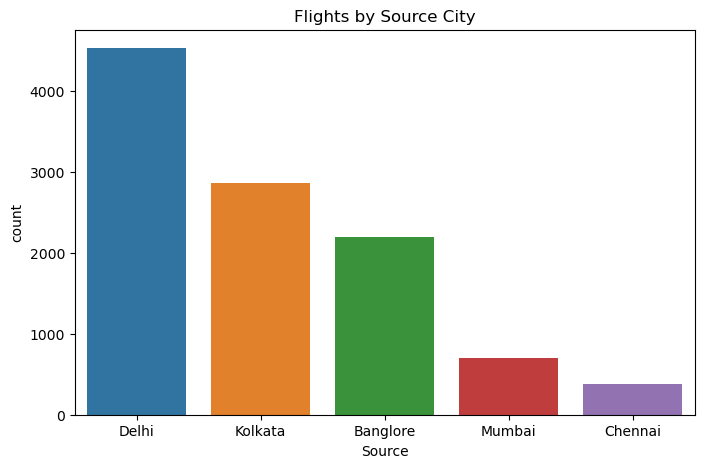

In [137]:
# Flights by Source City
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Source', order=df['Source'].value_counts().index)
plt.title('Flights by Source City')
plt.show()

Delhi is the leading source city for flights, followed by Kolkata and Bangalore, with Chennai and Mumbai contributing the least.

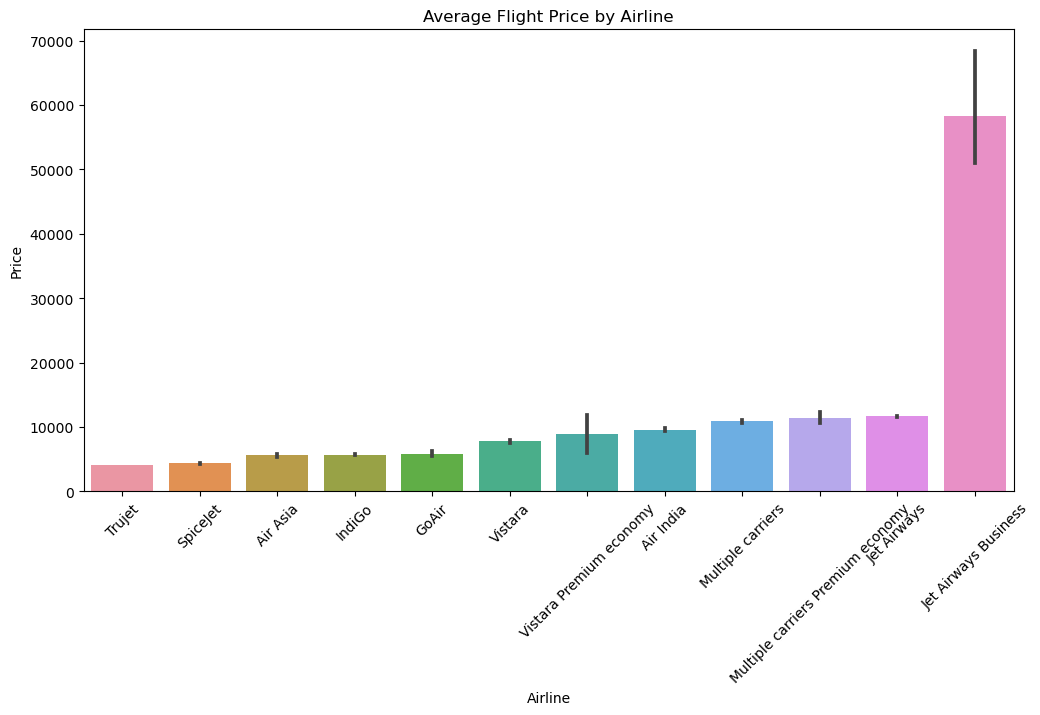

In [140]:
# Average price per airline 
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Airline', y='Price', estimator='mean', order=df.groupby('Airline')['Price'].mean().sort_values().index)
plt.xticks(rotation=45)
plt.title('Average Flight Price by Airline')
plt.show()

Jet Airways Business has by far the highest average flight price, while TruJet, SpiceJet, and Air Asia offer the most affordable fares.

### Final Checks Before Modeling

In [144]:
# Outlier removal
# Remove extreme price outliers above 99th percentile
upper_limit = df['Price'].quantile(0.99)
df = df[df['Price'] <= upper_limit]

# Remove extreme flight duration outliers 
upper_dur = df['Duration_mins'].quantile(0.99)
df = df[df['Duration_mins'] <= upper_dur]

In [146]:
print(df.columns)

Index(['Airline', 'Source', 'Destination', 'Route', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Duration_mins', 'Journey_Day',
       'Journey_Month', 'Journey_Weekday', 'Dep_Hour', 'Arrival_Hour'],
      dtype='object')


In [148]:
# Encode Categorical Features
# Columns like Airline, Source, Destination, Total_Stops, Additional_Info must be converted to numbers.
# One-hot encode categorical columns
categorical_cols = ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info']

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after encoding:", df_encoded.shape)

Shape after encoding: (10477, 38)


In [150]:
# Define Features (X) and Target (y)
X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

In [152]:
# Train-Test Split
from sklearn.model_selection import train_test_split

# Split into training (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (8381, 37)
Test shape: (2096, 37)


In [156]:
# Drop all string columns
obj_cols = X_train.select_dtypes(include='object').columns
if len(obj_cols) > 0:
    print(f"Dropping string columns: {list(obj_cols)}")
    X_train = X_train.drop(obj_cols, axis=1)
    X_test = X_test.drop(obj_cols, axis=1)

Dropping string columns: ['Route', 'Duration']


In [158]:
# Scale Numerical Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Data Modeling and Evaluation
#### Linear Regression 

In [164]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and Train Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

# Make Predictions
y_pred = lin_reg.predict(X_test_scaled)

# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Linear Regression Results:
Mean Absolute Error (MAE): 1615.48
Mean Squared Error (MSE): 4640305.87
Root Mean Squared Error (RMSE): 2154.14
R² Score: 0.7178


MAE (1615): On average, the model’s predictions are 1,615 off from the actual price.

RMSE (2154): Larger errors are penalized more, typical errors are about 2,154.

R² Score (0.718): About 72% of the variation in flight prices is explained by the model. An R² of 0.72 is strong for this kind of dataset (flight prices are influenced by many factors).

#### Random Forest Regressor 

In [170]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and Train the Model
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_scaled, y_train)


# Make Predictions
y_pred_rf = rf_reg.predict(X_test_scaled)

# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Random Forest Regressor Results:
Mean Absolute Error (MAE): 593.50
Mean Squared Error (MSE): 1169554.34
Root Mean Squared Error (RMSE): 1081.46
R² Score: 0.9289


MAE (593): much lower than Linear Regression (1,615)

RMSE (1,081): typical error size cut by ~50%

R² Score (0.93): explains 93% of price variation (better than Linear Regression's 72%)

Random Forest performs much better than Linear Regression. Errors are smaller. Model fits data more accurately.

#### XGBoost Regressor

In [174]:
from xgboost import XGBRegressor

# Initialize and Train the Model
xgb_reg = XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
xgb_reg.fit(X_train_scaled, y_train)

# Make Predictions
y_pred_xgb = xgb_reg.predict(X_test_scaled)

# Evaluate the Model
mae = mean_absolute_error(y_test, y_pred_xgb)
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

XGBoost Regressor Results:
Mean Absolute Error (MAE): 665.70
Mean Squared Error (MSE): 1116705.17
Root Mean Squared Error (RMSE): 1056.74
R² Score: 0.9321


MAE (666): slightly higher than Random Forest’s 593

RMSE (1,057): slightly better than Random Forest’s 1,081

R² Score (0.932): almost the same as Random Forest (0.929)


-> Both perform very well, but XGBoost has a slight edge on R² and RMSE, while Random Forest wins on MAE.

#### Best Model Based on Evaluation
Comparing all three models:

##### Linear Regression

- R²: 0.718

- RMSE: 2,154

Errors are the largest: least accurate

##### Random Forest Regressor

- R²: 0.929

- RMSE: 1,081

- MAE: 593

Strong performance with low errors

##### XGBoost Regressor

- R²: 0.932 (slightly better than Random Forest)

- RMSE: 1,057 (slightly better)

- MAE: 666 (slightly worse than Random Forest)

-> Winner: XGBoost Regressor 
Highest R² (0.932): explains the most variation in flight prices

Lowest RMSE (1,057): smallest typical error size

Performance is slightly better overall than Random Forest. Random Forest is very close and has slightly lower MAE, so either is a strong choice. But XGBoost edges out overall.